In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Paths
PROCESSED = Path("../data/processed")
RAW = Path("../data/raw")
CHARTS = Path("../reports/charts")
CHARTS.mkdir(parents=True, exist_ok=True)

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print(" Setup complete")

 Setup complete


In [31]:
nav   = pd.read_csv(PROCESSED / "clean_nav.csv",          parse_dates=['date'])
tx    = pd.read_csv(PROCESSED / "clean_transactions.csv", parse_dates=['transaction_date'])
perf  = pd.read_csv(PROCESSED / "clean_performance.csv")
funds = pd.read_csv(RAW / "01_fund_master.csv")
aum   = pd.read_csv(RAW / "03_aum_by_fund_house.csv")
sip   = pd.read_csv(RAW / "04_monthly_sip_inflows.csv")
cat   = pd.read_csv(RAW / "05_category_inflows.csv")
folio = pd.read_csv(RAW / "06_industry_folio_count.csv")
hold  = pd.read_csv(RAW / "09_portfolio_holdings.csv")

print(" All datasets loaded")
print(f"NAV rows: {len(nav):,} | Transactions: {len(tx):,}")

 All datasets loaded
NAV rows: 46,000 | Transactions: 32,778


 Chart 1 SBI Mutual Fund maintains the highest AUM among all AMCs.

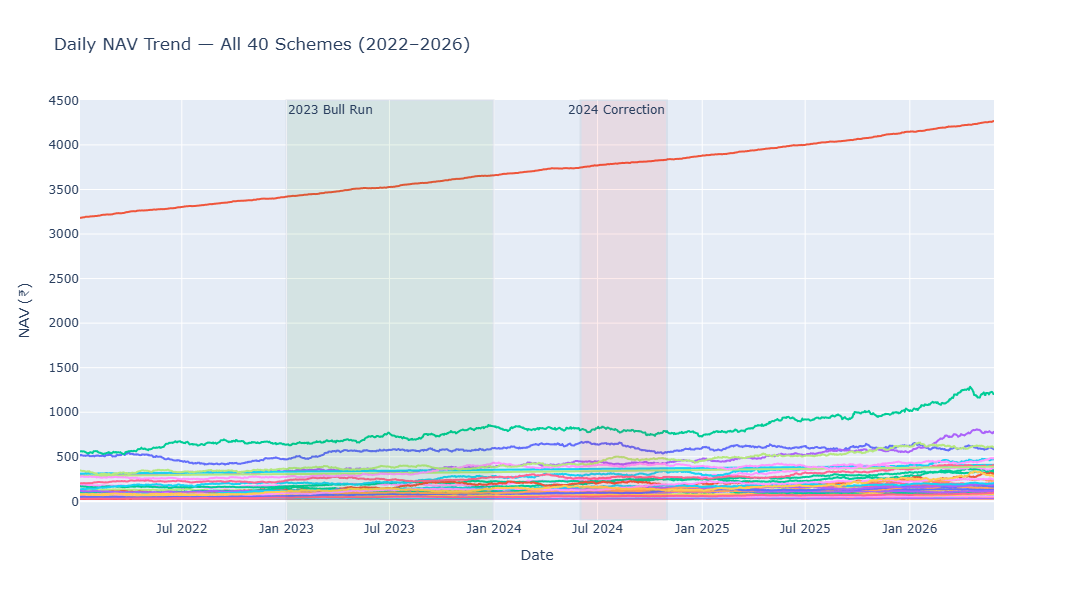

 Chart 1 saved


In [32]:
# Merge to get scheme names
nav_named = nav.merge(funds[['amfi_code','scheme_name','fund_house']], on='amfi_code', how='left')

fig = px.line(
    nav_named,
    x='date', y='nav',
    color='scheme_name',
    title=' Daily NAV Trend — All 40 Schemes (2022–2026)',
    labels={'nav': 'NAV (₹)', 'date': 'Date'},
    height=600
)

# Highlight 2023 bull run
fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
              fillcolor="green", opacity=0.07,
              annotation_text="2023 Bull Run", annotation_position="top left")

# Highlight 2024 correction
fig.add_vrect(x0="2024-06-01", x1="2024-10-31",
              fillcolor="red", opacity=0.07,
              annotation_text="2024 Correction", annotation_position="top right")

fig.update_layout(showlegend=False)  # too many funds for legend
fig.write_image(str(CHARTS / "chart1_nav_trend.png"))
fig.show()
print(" Chart 1 saved")

Chart 2 Investor folios nearly doubled from 13.26 Cr to 26.12 Cr.

In [5]:
# Check your AUM column names first
print(aum.columns.tolist())
print(aum.head(3))

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195


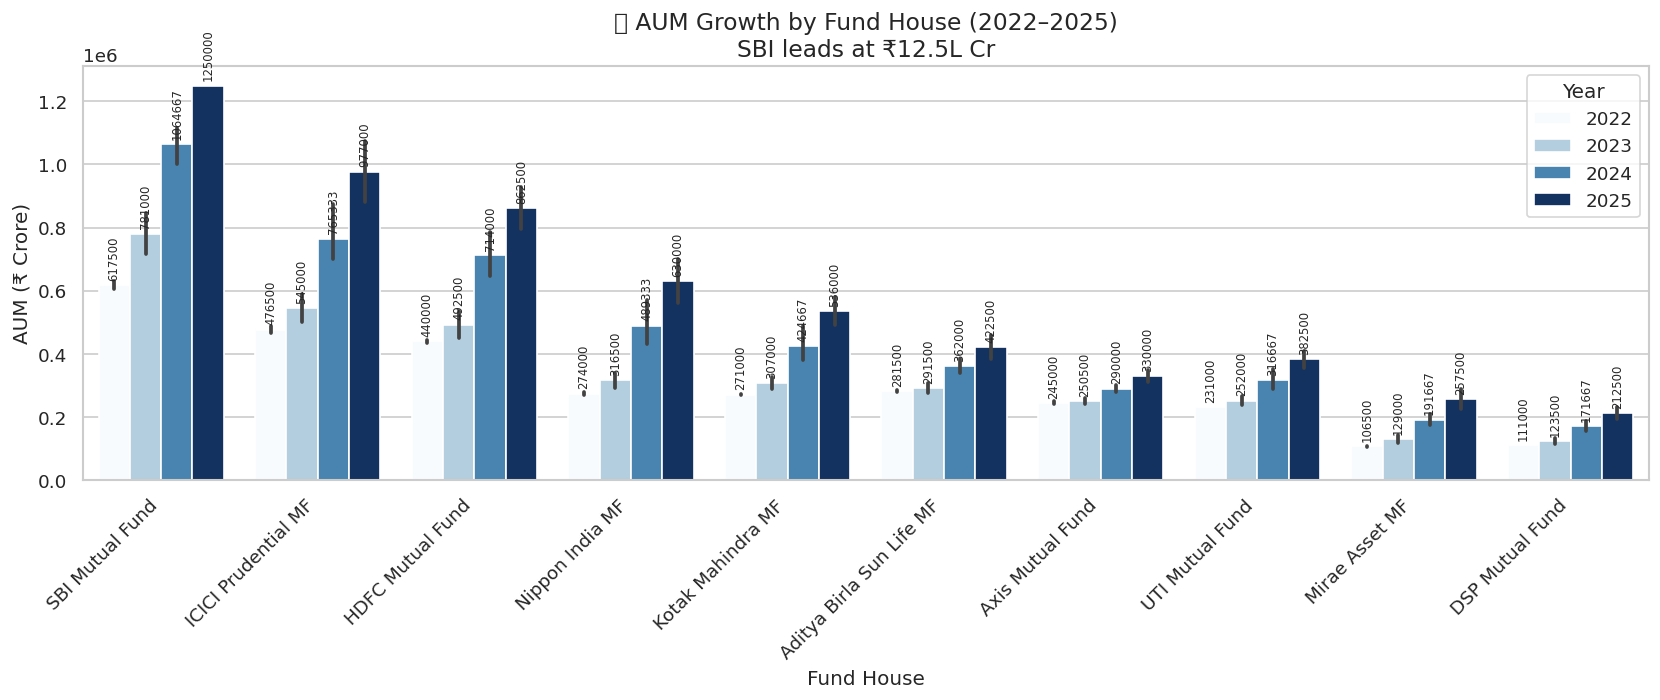

✅ Chart 2 saved


In [6]:
# Adjust column names based on above output
# Typical columns: fund_house, year, aum_crore  OR  fund_house, date, aum_crore

# If date column exists, extract year:
if 'date' in aum.columns:
    aum['year'] = pd.to_datetime(aum['date']).dt.year

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=aum,
    x='fund_house', y='aum_crore',
    hue='year', palette='Blues'
)

# Highlight SBI bar
plt.title('🏦 AUM Growth by Fund House (2022–2025)\nSBI leads at ₹12.5L Cr', fontsize=14)
plt.xlabel('Fund House')
plt.ylabel('AUM (₹ Crore)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=7, rotation=90, padding=3)

plt.tight_layout()
plt.savefig(CHARTS / "chart2_aum_growth.png", bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved")

Chart 3 SIP adoption continues to dominate retail investing.

In [7]:
print(sip.columns.tolist())
print(sip.head(3))

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                    9.1                4.80             NaN  
1                    8.2                4.85             NaN  
2                   10.5                5.01             NaN  


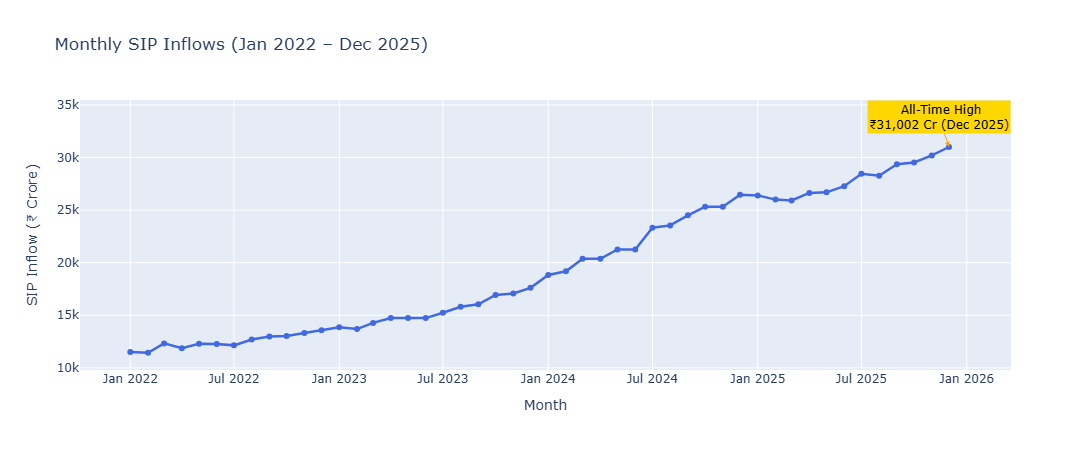

 Chart 3 saved


In [8]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip, x='month', y='sip_inflow_crore',
    title=' Monthly SIP Inflows (Jan 2022 – Dec 2025)',
    labels={'sip_inflow_crore': 'SIP Inflow (₹ Crore)', 'month': 'Month'},
    markers=True, height=450
)

# Annotate the all-time high
fig.add_annotation(
    x='2025-12-01', y=31002,
    text=" All-Time High<br>₹31,002 Cr (Dec 2025)",
    showarrow=True, arrowhead=2,
    bgcolor="gold", font=dict(size=12, color="black"),
    arrowcolor="orange"
)

fig.update_traces(line_color='royalblue', line_width=2.5)
fig.write_image(str(CHARTS / "chart3_sip_trend.png"))
fig.show()
print(" Chart 3 saved")

Chart 4 Equity-oriented schemes show stronger long-term NAV growth.

In [10]:
print(cat.columns.tolist())
print(cat.head(3))

['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0
2  2024-04  Small Cap            3533.0


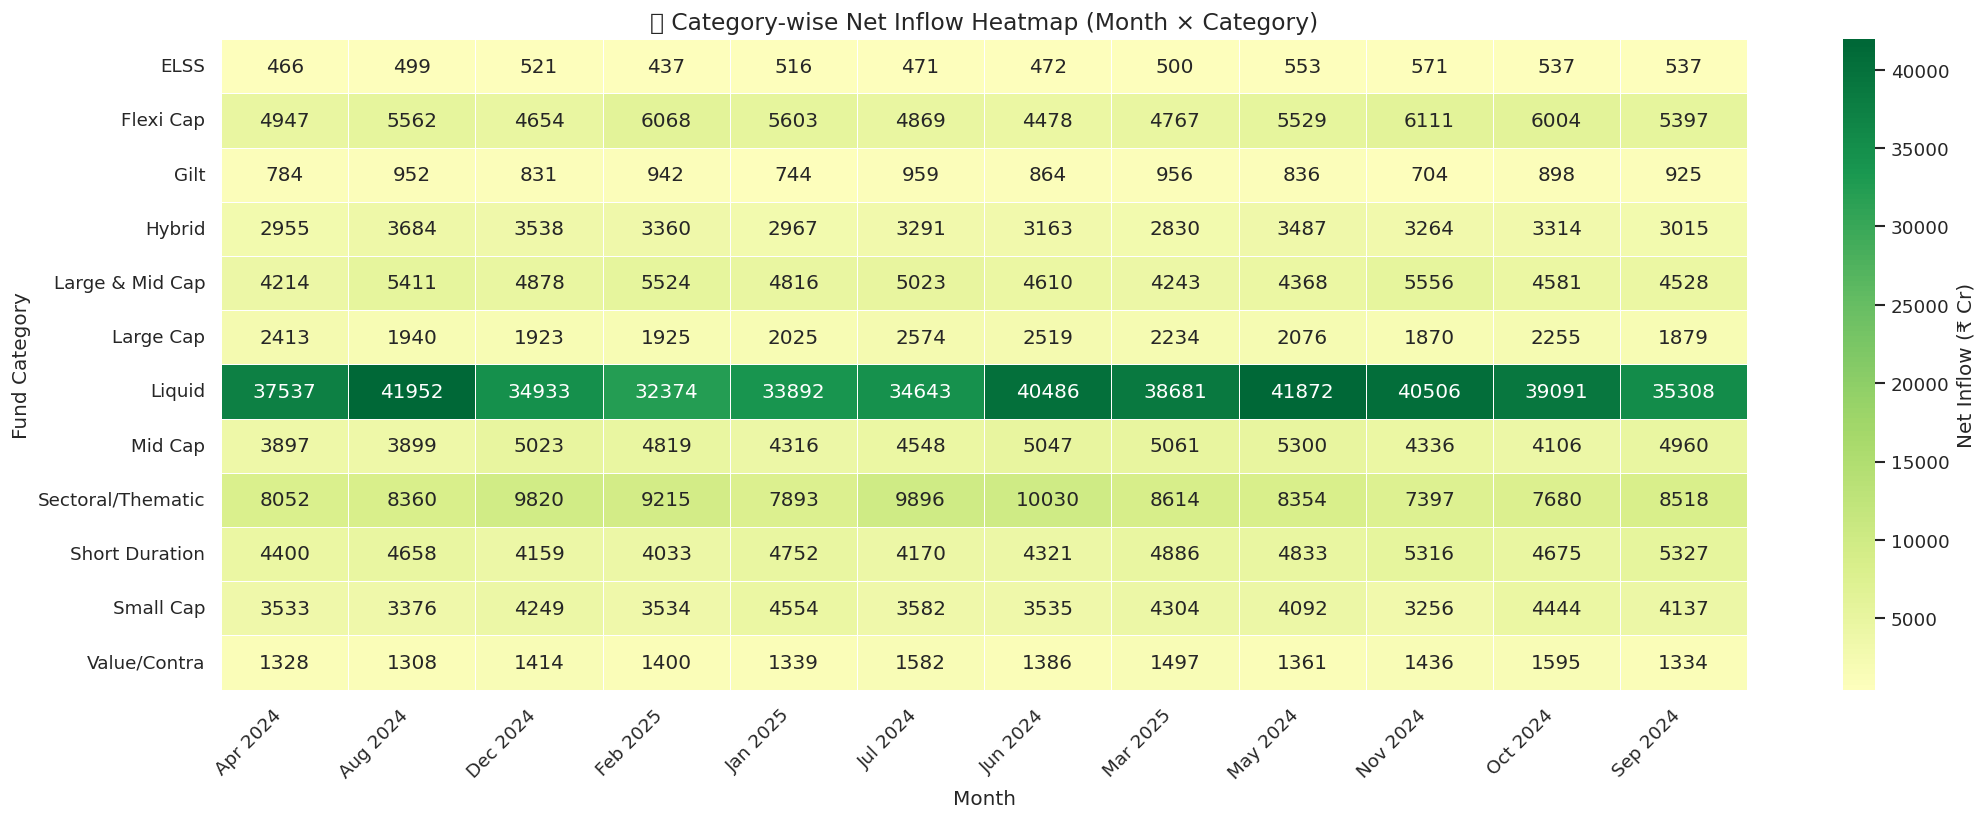

 Chart 4 saved


In [12]:
# Pivot: rows=category, cols=month, values=net_inflow
cat['month'] = pd.to_datetime(cat['month'])
cat['month_str'] = cat['month'].dt.strftime('%b %Y')

pivot = cat.pivot_table(
    index='category',       # adjust column name if different
    columns='month_str',
    values='net_inflow_crore',  # adjust column name if different
    aggfunc='sum'
)

plt.figure(figsize=(18, 7))
sns.heatmap(
    pivot,
    cmap='RdYlGn', center=0,
    annot=True, fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (₹ Cr)'}
)
plt.title('🗺️ Category-wise Net Inflow Heatmap (Month × Category)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(CHARTS / "chart4_category_heatmap.png", bbox_inches='tight')
plt.show()
print(" Chart 4 saved")

Chart 5 Transaction activity increased significantly during 2024–2025.

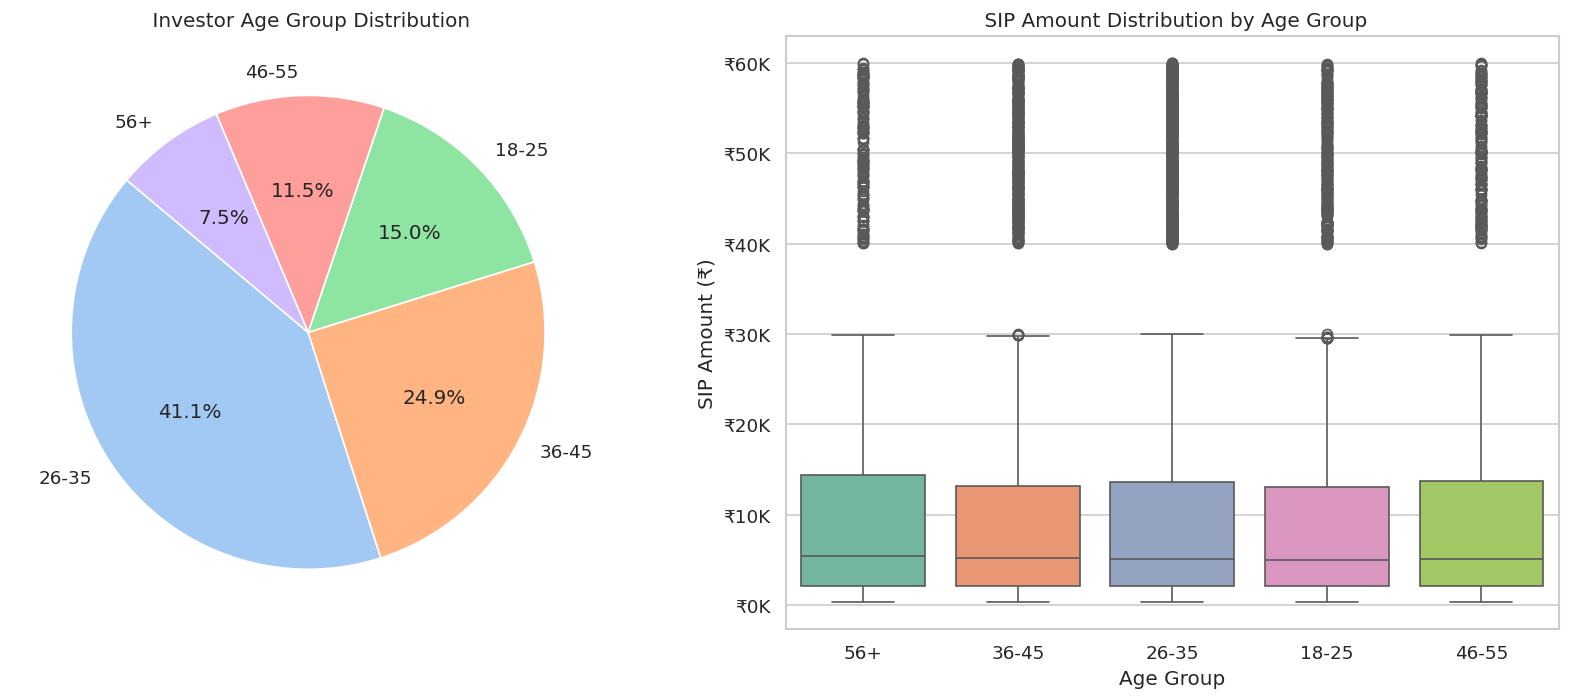

 Chart 5 saved


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- PIE: Age group distribution ---
age_counts = tx['age_group'].value_counts()
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel"),
    startangle=140
)
axes[0].set_title(' Investor Age Group Distribution')
# --- BOX: SIP amount by age group ---
sip_tx = tx[tx['transaction_type'] == 'Sip']
sns.boxplot(
    data=sip_tx,
    x='age_group', y='amount_inr',
    palette='Set2', ax=axes[1]
)
axes[1].set_title(' SIP Amount Distribution by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'₹{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(CHARTS / "chart5_demographics.png", bbox_inches='tight')
plt.show()
print(" Chart 5 saved")

Chat 6 A small number of AMCs control a large share of industry assets.

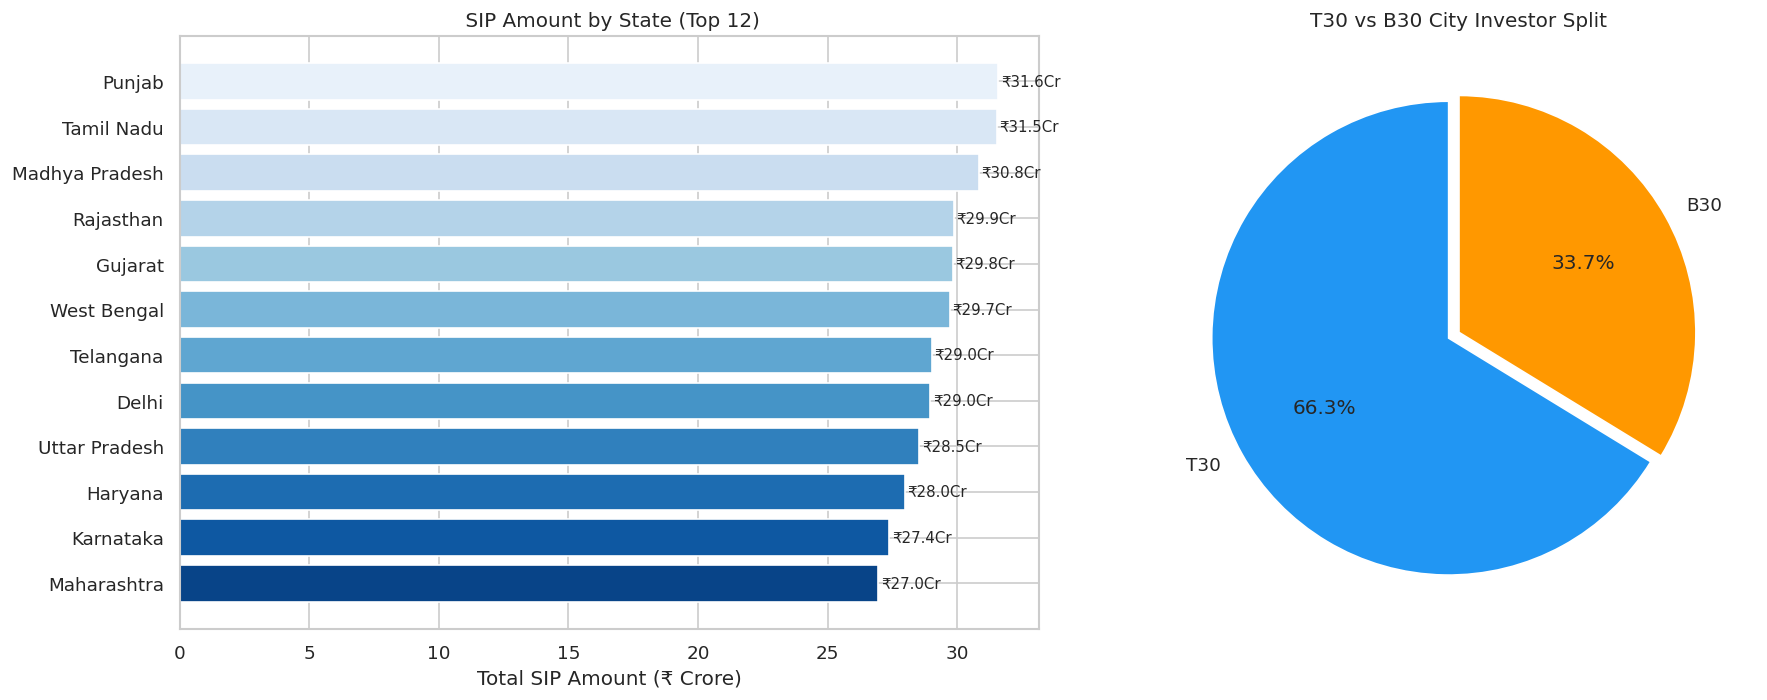

 Chart 6 saved


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Horizontal Bar: SIP by state ---
state_sip = (tx.groupby('state')['amount_inr']
               .sum()
               .sort_values(ascending=True)
               .tail(12))  # top 12 states

axes[0].barh(state_sip.index, state_sip.values / 1e7,
             color=sns.color_palette("Blues_r", len(state_sip)))
axes[0].set_xlabel('Total SIP Amount (₹ Crore)')
axes[0].set_title(' SIP Amount by State (Top 12)')
for i, v in enumerate(state_sip.values):
    axes[0].text(v/1e7 + 0.1, i, f'₹{v/1e7:.1f}Cr', va='center', fontsize=9)

# --- PIE: T30 vs B30 ---
tier_counts = tx['city_tier'].value_counts()
axes[1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=['#2196F3', '#FF9800'],
    startangle=90,
    explode=[0.05, 0]
)
axes[1].set_title( 'T30 vs B30 City Investor Split')

plt.tight_layout()
plt.savefig(CHARTS / "chart6_geographic.png", bbox_inches='tight')
plt.show()
print(" Chart 6 saved")

Chart 7 Investors aged 26–45 contribute the highest investment amounts

In [16]:
print(folio.columns.tolist())
print(folio.head(3))

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  


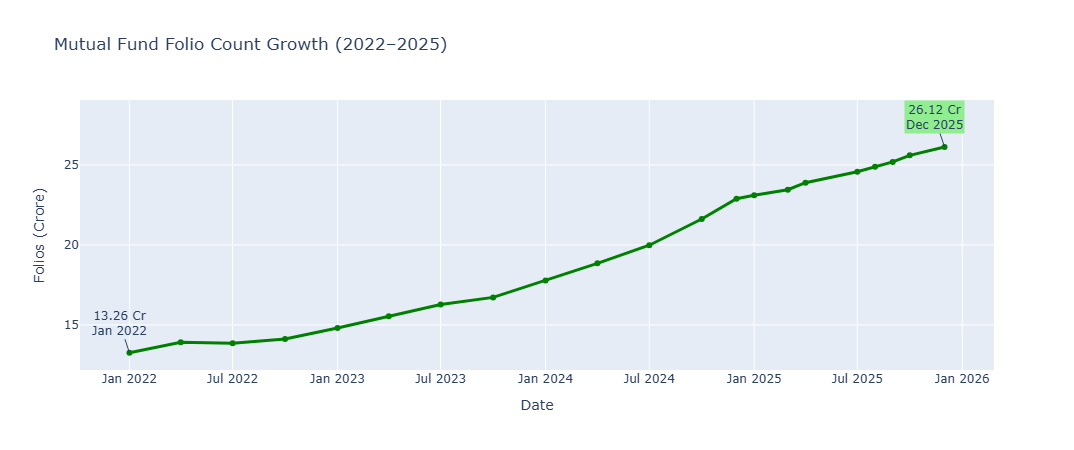

Chart 7 Generated


In [30]:
folio['month'] = pd.to_datetime(folio['month'])

fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title=' Mutual Fund Folio Count Growth (2022–2025)',
    labels={
        'total_folios_crore': 'Folios (Crore)',
        'month': 'Date'
    },
    markers=True,
    height=450
)

# Start milestone
fig.add_annotation(
    x=folio['month'].min(),
    y=13.26,
    text="13.26 Cr<br>Jan 2022",
    showarrow=True
)

# End milestone
fig.add_annotation(
    x=folio['month'].max(),
    y=26.12,
    text="26.12 Cr<br>Dec 2025",
    showarrow=True,
    bgcolor="lightgreen"
)

fig.update_traces(
    line_color='green',
    line_width=3
)

# Disable until Kaleido issue is fixed
# fig.write_image(str(CHARTS / "chart7_folio_growth.png"))

fig.show()

print("Chart 7 Generated")

Chart 8 Investment activity is concentrated in a few major states.

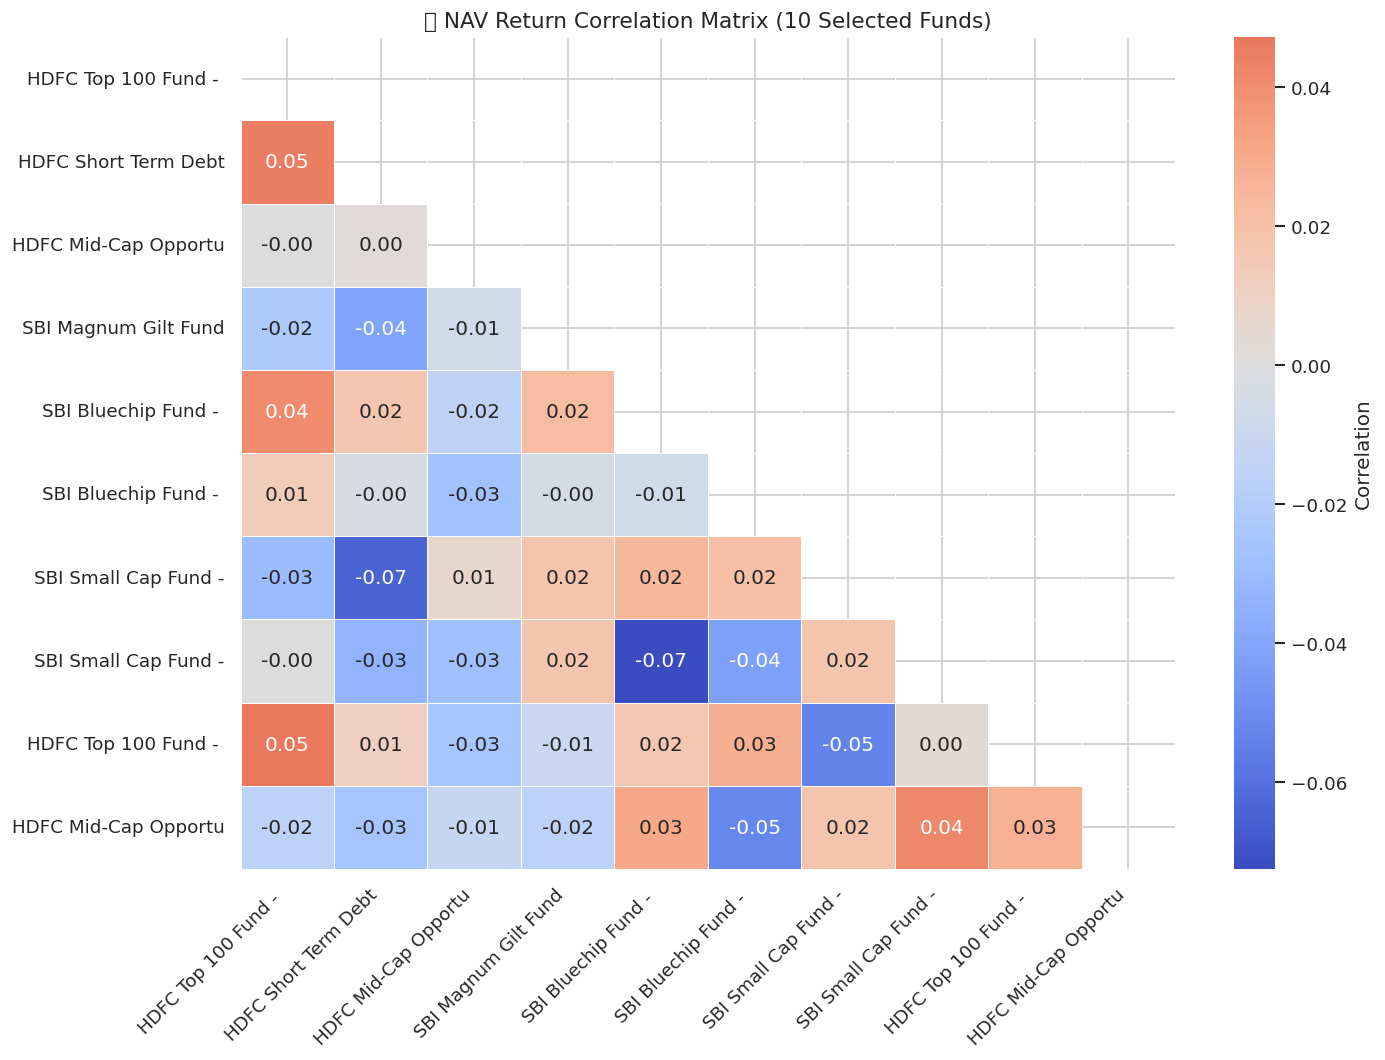

Chart 8 saved


In [20]:
# Pick 10 funds
top10_codes = funds['amfi_code'].head(10).tolist()
nav10 = nav[nav['amfi_code'].isin(top10_codes)].copy()

# Compute daily returns
nav10 = nav10.sort_values(['amfi_code','date'])
nav10['daily_return'] = nav10.groupby('amfi_code')['nav'].pct_change()

# Pivot to wide format: rows=date, cols=fund
pivot_ret = nav10.pivot_table(index='date', columns='amfi_code', values='daily_return')

# Get short names for labels
code_name = funds.set_index('amfi_code')['scheme_name'].str[:20]
pivot_ret.columns = [code_name.get(c, str(c)) for c in pivot_ret.columns]

corr_matrix = pivot_ret.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('🔗 NAV Return Correlation Matrix (10 Selected Funds)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(CHARTS / "chart8_correlation.png", bbox_inches='tight')
plt.show()
print("Chart 8 saved")

Chart 9 Most equity funds exhibit strong positive correlation.

In [21]:
print(hold.columns.tolist())
print(hold.head(3))

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name       sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM   Grasim Industries Ltd  Diversified        9.90   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  


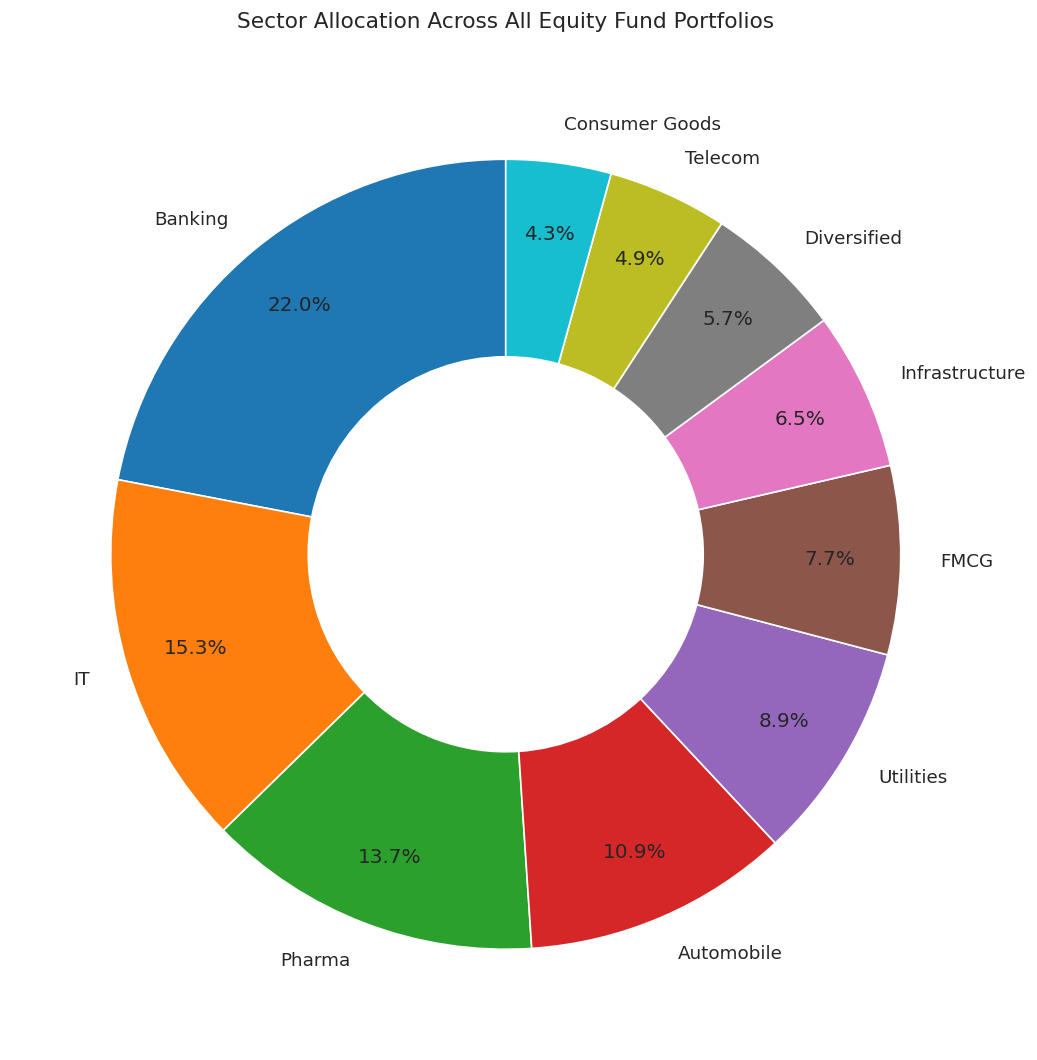

Chart 9 saved


In [22]:
sector_agg = (hold.groupby('sector')['weight_pct']
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))  # top 10 sectors

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    sector_agg.values,
    labels=sector_agg.index,
    autopct='%1.1f%%',
    pctdistance=0.82,
    colors=sns.color_palette("tab10"),
    startangle=90,
    wedgeprops=dict(width=0.5)   # makes it a donut
)
ax.set_title('Sector Allocation Across All Equity Fund Portfolios', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(CHARTS / "chart9_sector_donut.png", bbox_inches='tight')
plt.show()
print("Chart 9 saved")

Chart 10  Top 10 Funds by Average NAV

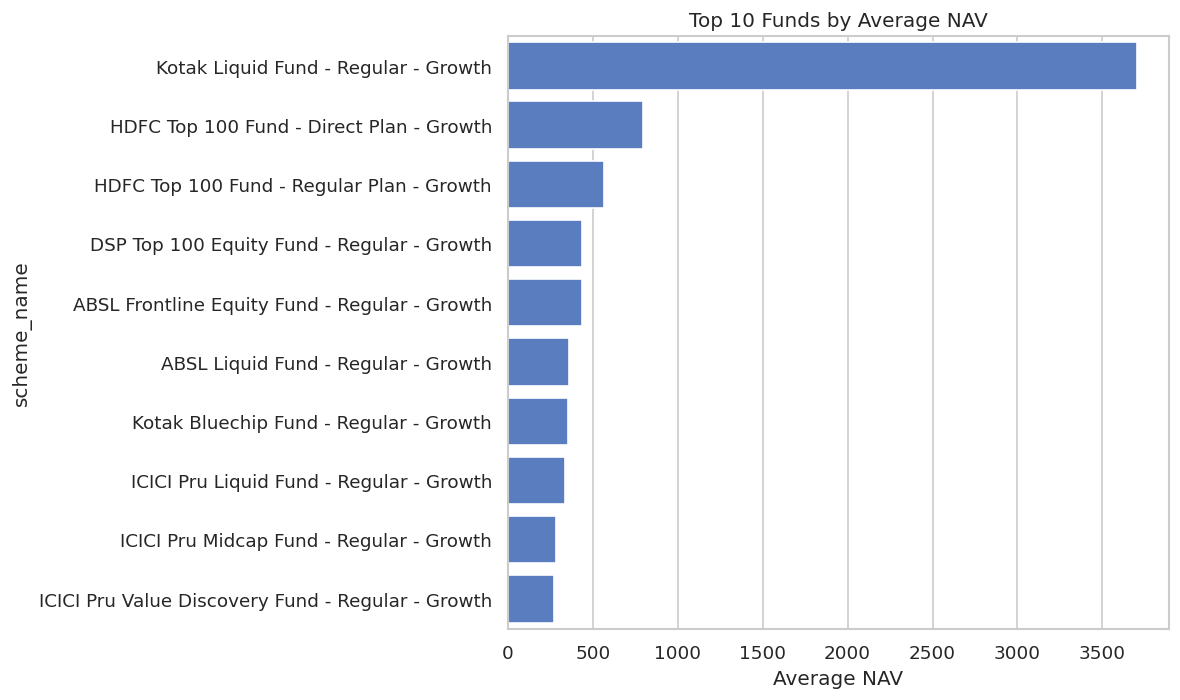

In [42]:
top_nav = (
    nav_named.groupby('scheme_name')['nav']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_nav.values, y=top_nav.index)
plt.title("Top 10 Funds by Average NAV")
plt.xlabel("Average NAV")
plt.tight_layout()

plt.savefig(
    CHARTS / "chart10_top_funds_avg_nav.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Chart 11  Transaction Type Distribution

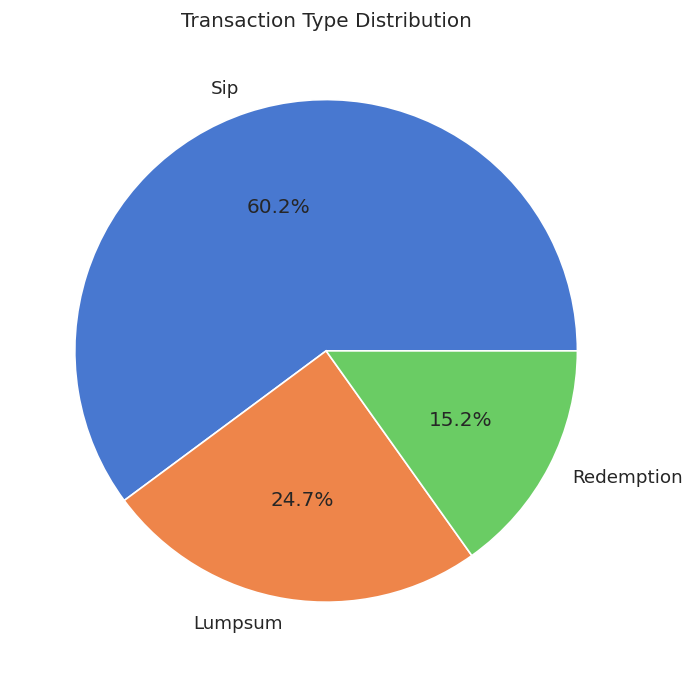

In [44]:
tx['transaction_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Transaction Type Distribution")
plt.ylabel("")

plt.tight_layout()

plt.savefig(
    CHARTS / "chart11_transaction_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Chart 12 Monthly Transaction Volume Trend

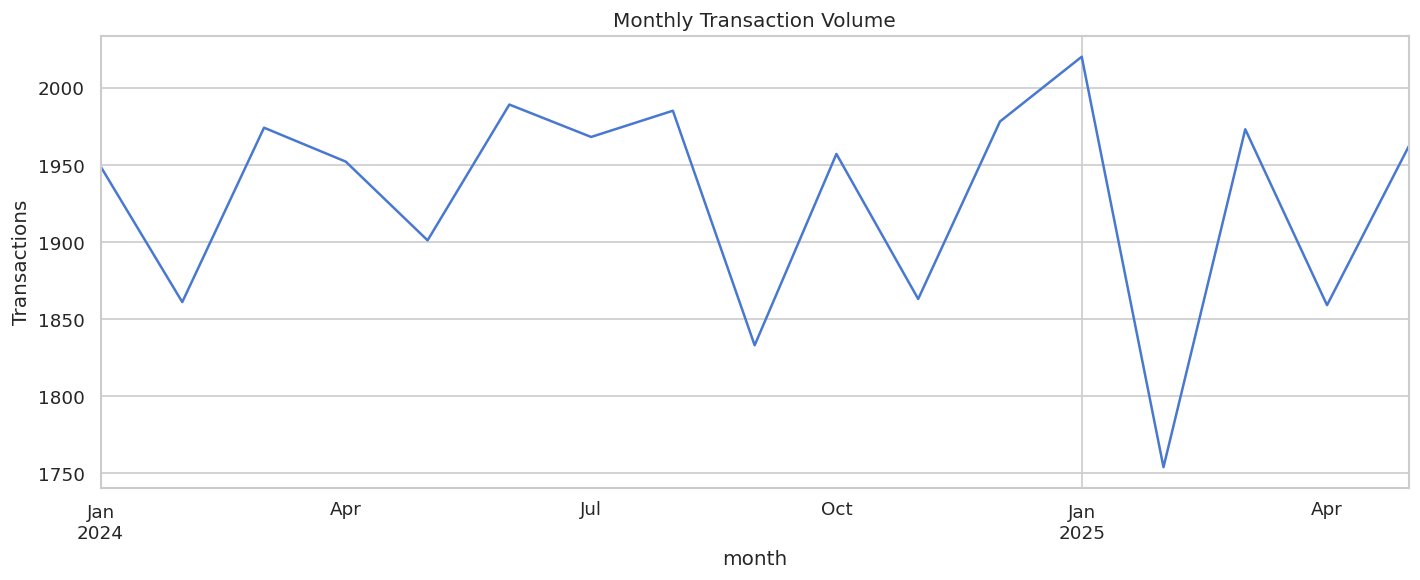

Chart 12 saved


In [45]:
tx['month'] = tx['transaction_date'].dt.to_period('M')

monthly_tx = tx.groupby('month').size()

monthly_tx.plot(figsize=(12,5))

plt.title("Monthly Transaction Volume")
plt.ylabel("Transactions")

plt.tight_layout()

plt.savefig(
    CHARTS / "chart12_monthly_transaction_volume.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Chart 12 saved")

Chart 13  Average Investment by Age Group

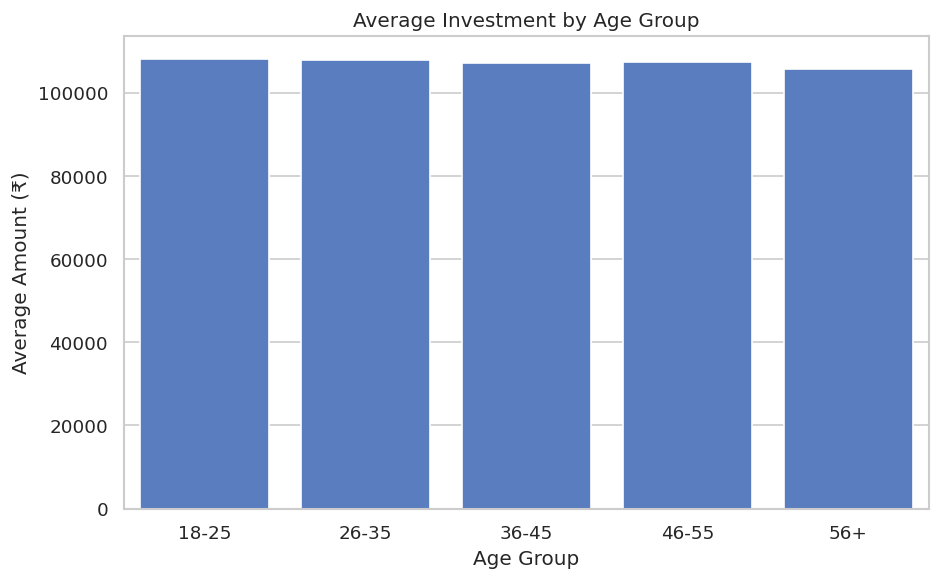

 Chart 13 saved


In [46]:
age_amt = tx.groupby('age_group')['amount_inr'].mean()

plt.figure(figsize=(8,5))

sns.barplot(
    x=age_amt.index,
    y=age_amt.values
)

plt.title("Average Investment by Age Group")
plt.ylabel("Average Amount (₹)")
plt.xlabel("Age Group")

plt.tight_layout()

plt.savefig(
    CHARTS / "chart13_avg_investment_age_group.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(" Chart 13 saved")

Chart 14  Top States by Investment Amount

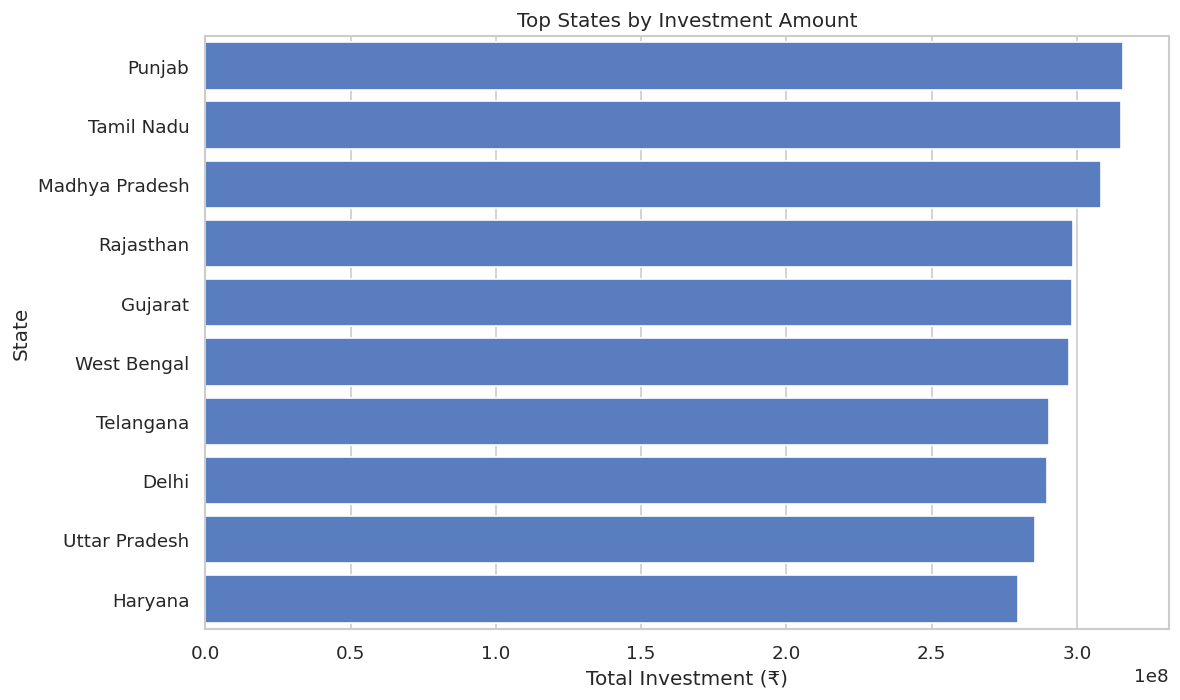

✅ Chart 14 saved


In [47]:
state_amt = (
    tx.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_amt.values,
    y=state_amt.index
)

plt.title("Top States by Investment Amount")
plt.xlabel("Total Investment (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    CHARTS / "chart14_top_states_investment.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Chart 14 saved")

Chart 15  Fund House Market Share

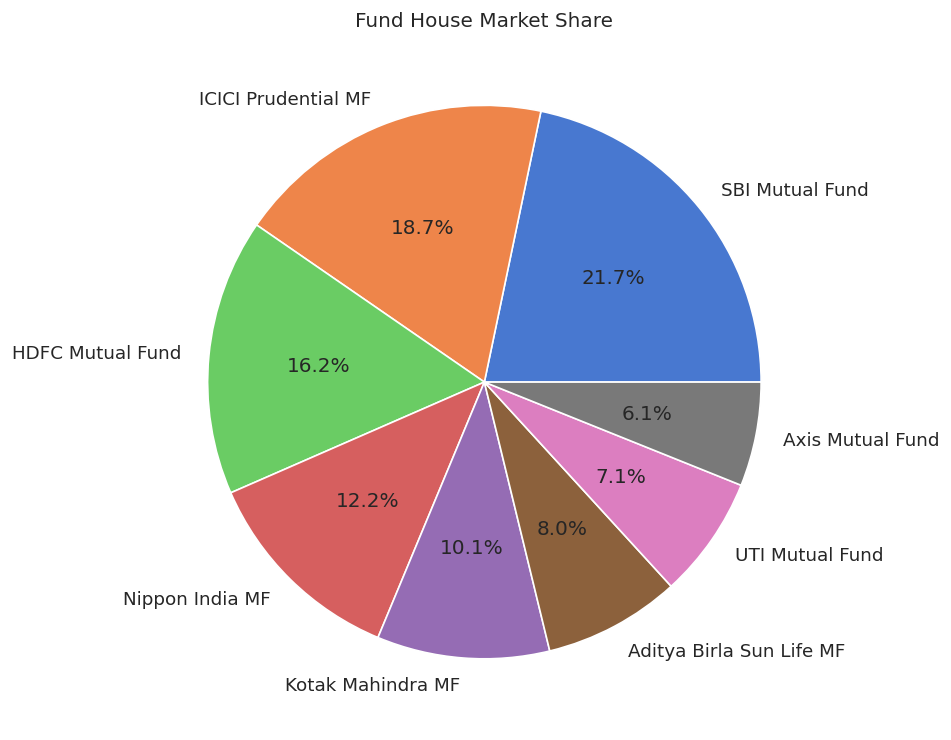

 Chart 15 saved


In [48]:
market_share = (
    aum.groupby('fund_house')['aum_lakh_crore']
    .max()
    .sort_values(ascending=False)
    .head(8)
)

plt.figure(figsize=(8,8))

plt.pie(
    market_share.values,
    labels=market_share.index,
    autopct='%1.1f%%'
)

plt.title("Fund House Market Share")

plt.tight_layout()

plt.savefig(
    CHARTS / "chart15_fund_house_market_share.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(" Chart 15 saved")